<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna
 En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

frecuencia f0
 arbitraria, por ejemplo f0=fS/N=Δf
 
energía normalizada, es decir energía (o varianza) unitaria
Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
. Siendo n
 la secuencia que simula la interferencia, y s
 la senoidal descrita anteriormente.
La potencia del ruido será Pn=kn.Pq
 W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212
.
finalmente, n
 será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2
 Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
.

# Introducción

 ## Introducción

En la elaboración de este trabajo se estudia el comportamiento de un ADC de ( B ) bits mediante la simulación de una señal senoidal con ruido Gaussiano. Se analiza el proceso de cuantización, el error introducido y su impacto en el dominio espectral.

Se evalúa la influencia de la cantidad de bits y del nivel de ruido analógico sobre los pisos de ruido y la calidad de la señal digitalizada, comparando los resultados obtenidos con las predicciones teóricas.

    

# Ejercicio a:
## Código, sus respectivos gráficos y analisis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# FUNCIÓN SENOIDAL
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx
# PARÁMETROS GENERALES
fs = 1000          # frecuencia de muestreo [Hz]
N = 1000           # cantidad de muestras
ts = 1 / fs
tt = np.arange(N) * ts

VF = 2.0           # rango analógico ±VF
B = 4              # bits del ADC
kn = 1             # factor de potencia del ruido
EPS = 1e-12

# frecuencia de la senoide
df = fs / N
f0 = 1        

# SEÑAL SENOIDAL DE POTENCIA UNITARIA
# para una senoide, potencia unitaria -> A = sqrt(2)
vmax = np.sqrt(2)
dc = 0
ph = 0

tt, s = mi_funcion_sen(vmax, dc, f0, ph, N, fs)
# CUANTIZADOR
q = (2 * VF) / (2**B)     # paso de cuantización
Pq = q**2 / 12            # potencia teórica del ruido de cuantización

# RUIDO ADITIVO
Pn = kn * Pq              # potencia del ruido analógico
sigma_n = np.sqrt(Pn)

np.random.seed(0)         # para reproducibilidad
n = np.random.normal(0, sigma_n, N)

# señal de entrada al ADC
sR = s + n

# SALIDA DEL ADC
# primero recorto al rango del ADC
sR_clip = np.clip(sR, -VF, VF)

# cuantización
sq = np.round(sR_clip / q) * q

# error de cuantización: salida - entrada al cuantizador
e = sq - sR_clip

# chequeo rápido
print(f'Error máximo = {np.max(np.abs(e)):.6f} V  (debe ser <= {q/2:.6f} V)')

Error máximo = 0.124954 V  (debe ser <= 0.125000 V)


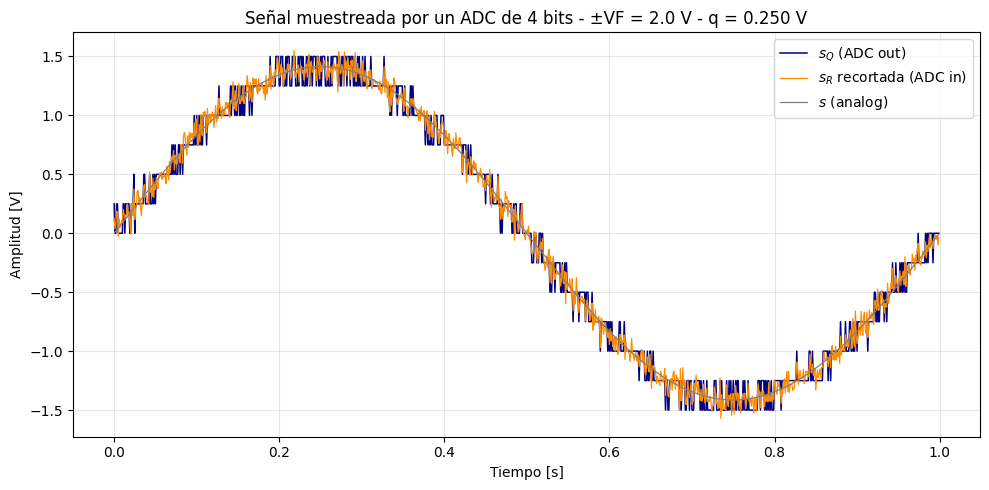

In [3]:
# FIGURA 1 - DOMINIO TEMPORAL
plt.figure(figsize=(10, 5))
plt.plot(tt, sq, label=r'$s_Q$ (ADC out)', color='navy', linewidth=1.1)
plt.plot(tt, sR_clip, label=r'$s_R$ recortada (ADC in)', color='darkorange', linewidth=0.9)
plt.plot(tt, s, label=r'$s$ (analog)', color='gray', linewidth=0.9)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF:.1f} V - q = {q:.3f} V')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


El gráfico muestra cómo el ADC transforma la señal analógica en una señal discreta. Se puede observar que la señal cuantizada sigue la forma de la senoidal original pero toma valores escalonados, efecto propio de la cuantización. La señal de entrada al ADC presenta pequeñas variaciones respecto a la senoidal pura debido al ruido gaussiano aditivo. La diferencia entre ambas señales corresponde al error de cuantización, que visualmente se nota como pequeñas desviaciones entre la curva de entrada y los escalones de salida, y que teóricamente está acotado entre ±q/2.


--- VERIFICACIÓN DE PISOS ---
Piso analógico teórico:   -49.82 dB
Piso analógico espectral: -49.96 dB
Piso digital teórico:     -49.82 dB
Piso digital espectral:   -49.71 dB
-----------------------------------


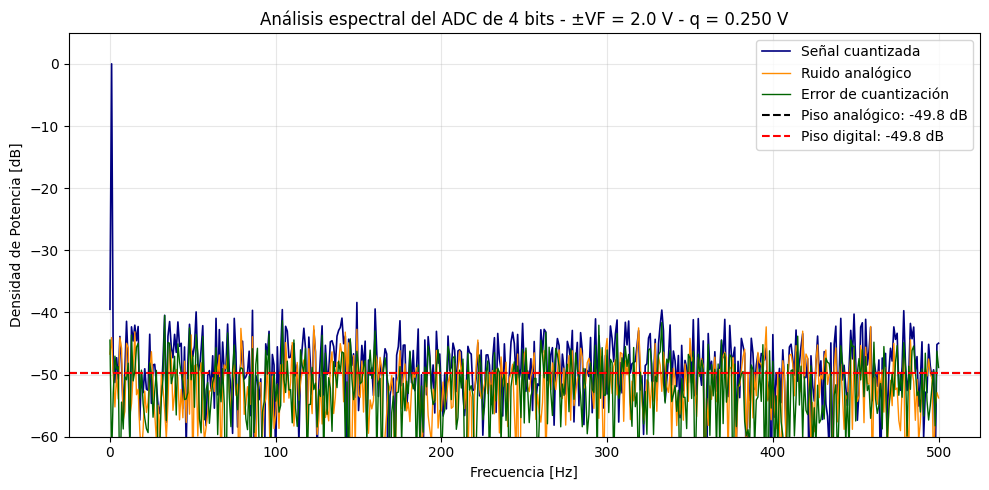

In [9]:
# FIGURA 2 - ESPECTROS / DENSIDAD DE POTENCIA
# eje de frecuencias
ff = np.arange(N) * df
bbool = ff <= fs/2

# ruido analógico puro
Nmod = np.abs(np.fft.fft(n)) / N
Npsd = (Nmod**2) * 2 * N / fs
Ndb = 10 * np.log10(Npsd + EPS)

# error de cuantización puro
Emod = np.abs(np.fft.fft(e)) / N
Epsd = (Emod**2) * 2 * N / fs
Edb = 10 * np.log10(Epsd + EPS)

# señal cuantizada
SQmod = np.abs(np.fft.fft(sq)) / N
SQpsd = (SQmod**2) * 2 * N / fs
SQdb = 10 * np.log10(SQpsd + EPS)

# pisos teóricos
n0_analog = 10 * np.log10((2 * Pn / fs) + EPS)
n0_digital = 10 * np.log10((2 * Pq / fs) + EPS)

# verificación doble de pisos
k0 = int(f0 / df)
mask = bbool.copy()
mask[max(k0-1, 0):min(k0+2, len(mask))] = False

piso_n_medio = 10 * np.log10(np.mean(Npsd[mask]) + EPS)
piso_q_medio = 10 * np.log10(np.mean(Epsd[mask]) + EPS)
print('--- VERIFICACIÓN DE PISOS ---')
print(f'Piso analógico teórico:   {n0_analog:.2f} dB')
print(f'Piso analógico espectral: {piso_n_medio:.2f} dB')
print(f'Piso digital teórico:     {n0_digital:.2f} dB')
print(f'Piso digital espectral:   {piso_q_medio:.2f} dB')
print('-----------------------------------')

plt.figure(figsize=(10, 5))
plt.plot(ff[bbool], SQdb[bbool], color='navy', linewidth=1.2, label='Señal cuantizada')
plt.plot(ff[bbool], Ndb[bbool], color='darkorange', linewidth=1.0, label='Ruido analógico')
plt.plot(ff[bbool], Edb[bbool], color='darkgreen', linewidth=1.0, label='Error de cuantización')
plt.axhline(n0_analog, color='black', linestyle='--', linewidth=1.5,
            label=f'Piso analógico: {n0_analog:.1f} dB')
plt.axhline(n0_digital, color='red', linestyle='--', linewidth=1.5,
            label=f'Piso digital: {n0_digital:.1f} dB')
plt.title(f'Análisis espectral del ADC de {B} bits - ±VF = {VF:.1f} V - q = {q:.3f} V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.ylim(-60, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


El espectro muestra un pico en frecuencias bajas correspondiente a la señal senoidal. El resto del espectro presenta un piso de ruido aproximadamente plano, lo que indica que tanto el ruido analógico como el error de cuantización se comportan como ruido blanco, distribuyendo su potencia uniformemente en todas las frecuencias. Como kn = 1 ambos ruidos tienen la misma potencia y sus pisos coinciden. La señal cuantizada total aparece por encima de ambos ya que los contiene a los dos. Para verificar la consistencia del modelo se calculó el piso de dos formas independientes, usando la fórmula teórica y promediando el espectro directamente, obteniendo valores que coinciden.

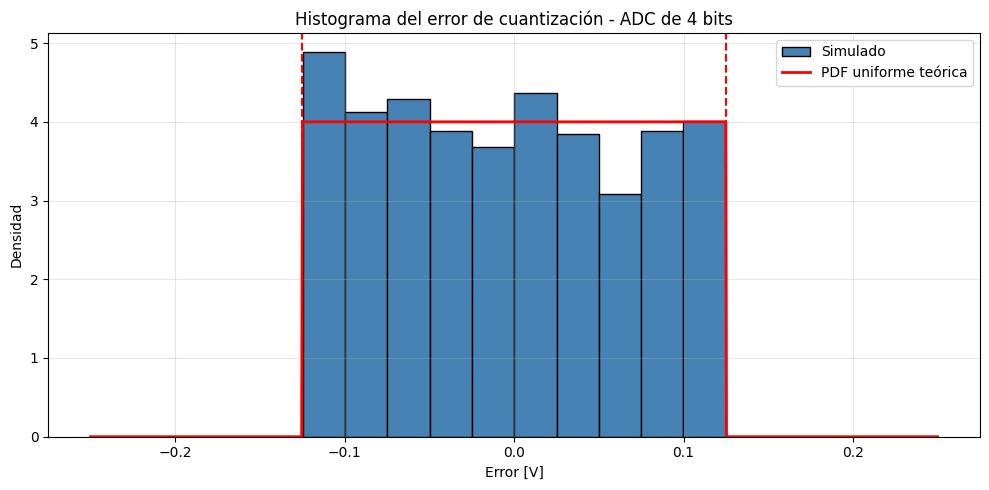

In [5]:
# FIGURA 3 - HISTOGRAMA DEL ERROR
plt.figure(figsize=(10, 5))
plt.hist(e, bins=10, density=True, color='steelblue', edgecolor='black', label='Simulado')

eje_e = np.linspace(-q, q, 1000)
pdf_teorica = 1 / q
pdf_uniforme = np.where((eje_e >= -q/2) & (eje_e <= q/2), pdf_teorica, 0)

plt.plot(eje_e, pdf_uniforme, color='red', linewidth=2, label='PDF uniforme teórica')
plt.axvline(q/2, color='red', linestyle='--')
plt.axvline(-q/2, color='red', linestyle='--')
plt.title(f'Histograma del error de cuantización - ADC de {B} bits')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

El histograma muestra la distribución del error de cuantización. Se puede ver que está contenido dentro del rango ±q/2, lo que confirma que el error nunca supera el medio paso de cuantización. Sin embargo, las barras no tienen exactamente la misma altura, lo que indica que con esta cantidad de muestras la distribución no converge perfectamente a la uniforme teórica. A medida que se aumenta N, las barras tenderían a igualarse y aproximarse mejor a la curva roja teórica.

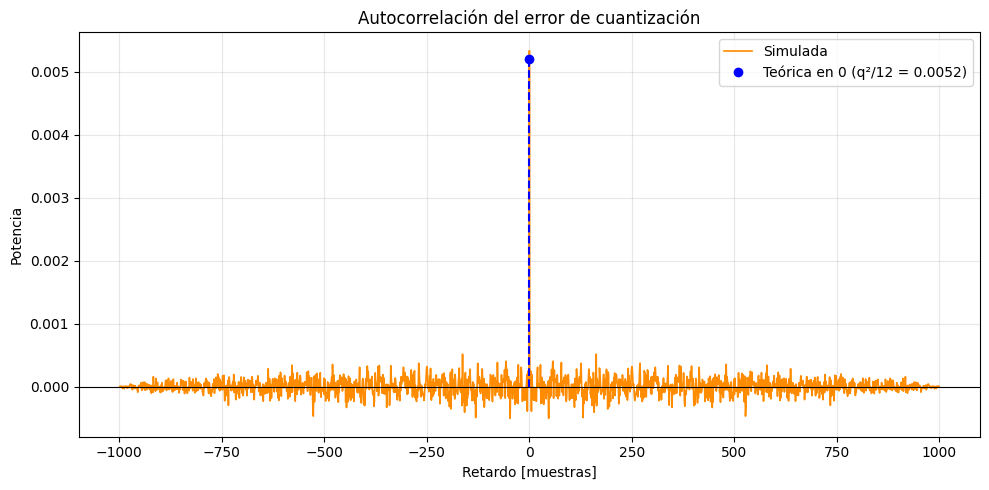

In [6]:
# FIGURA 4 - AUTOCORRELACIÓN DEL ERROR
varianza_teorica = q**2 / 12
autocorr_e = np.correlate(e, e, mode='full') / N
lags = np.arange(-N + 1, N)

plt.figure(figsize=(10, 5))
plt.plot(lags, autocorr_e, color='darkorange', linewidth=1.2, label='Simulada')
plt.axhline(0, color='black', linewidth=0.8)
plt.plot(0, varianza_teorica, 'o', color='blue',
         label=f'Teórica en 0 (q²/12 = {varianza_teorica:.4f})')
plt.vlines(0, 0, varianza_teorica, colors='blue', linestyles='--', linewidth=1.5)
plt.title('Autocorrelación del error de cuantización')
plt.xlabel('Retardo [muestras]')
plt.ylabel('Potencia')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

La autocorrelación del error de cuantización presenta un valor significativo únicamente en el retardo cero, coincidiendo con la varianza teórica q²/12, mientras que para el resto de los retardos se mantiene cercana a cero. Esto confirma que el error no está correlacionado entre muestras y se comporta como ruido blanco, validando el modelo teórico asumido. Si bien no es solicitado explícitamente en la consigna, se incluyó para verificar que el error de cuantización cumple con las propiedades esperadas.

In [8]:
# DATOS ÚTILES EN CONSOLA
print('-----------------------------------')
print(f'fs = {fs} Hz')
print(f'N = {N}')
print(f'df = {df} Hz')
print(f'f0 = {f0} Hz')
print(f'B = {B} bits')
print(f'VF = ±{VF} V')
print(f'q = {q:.6f} V')
print(f'Pq = {Pq:.6e} W')
print(f'Pn = {Pn:.6e} W')
print(f'sigma_n = {sigma_n:.6e} V')
print('-----------------------------------')


-----------------------------------
fs = 1000 Hz
N = 1000
df = 1.0 Hz
f0 = 1 Hz
B = 4 bits
VF = ±2.0 V
q = 0.250000 V
Pq = 5.208333e-03 W
Pn = 5.208333e-03 W
sigma_n = 7.216878e-02 V
-----------------------------------


# Ejercicio b:



b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
. Discutir los resultados respecto a lo obtenido en a).

## Desarrollo del código y analisís de los gráficos

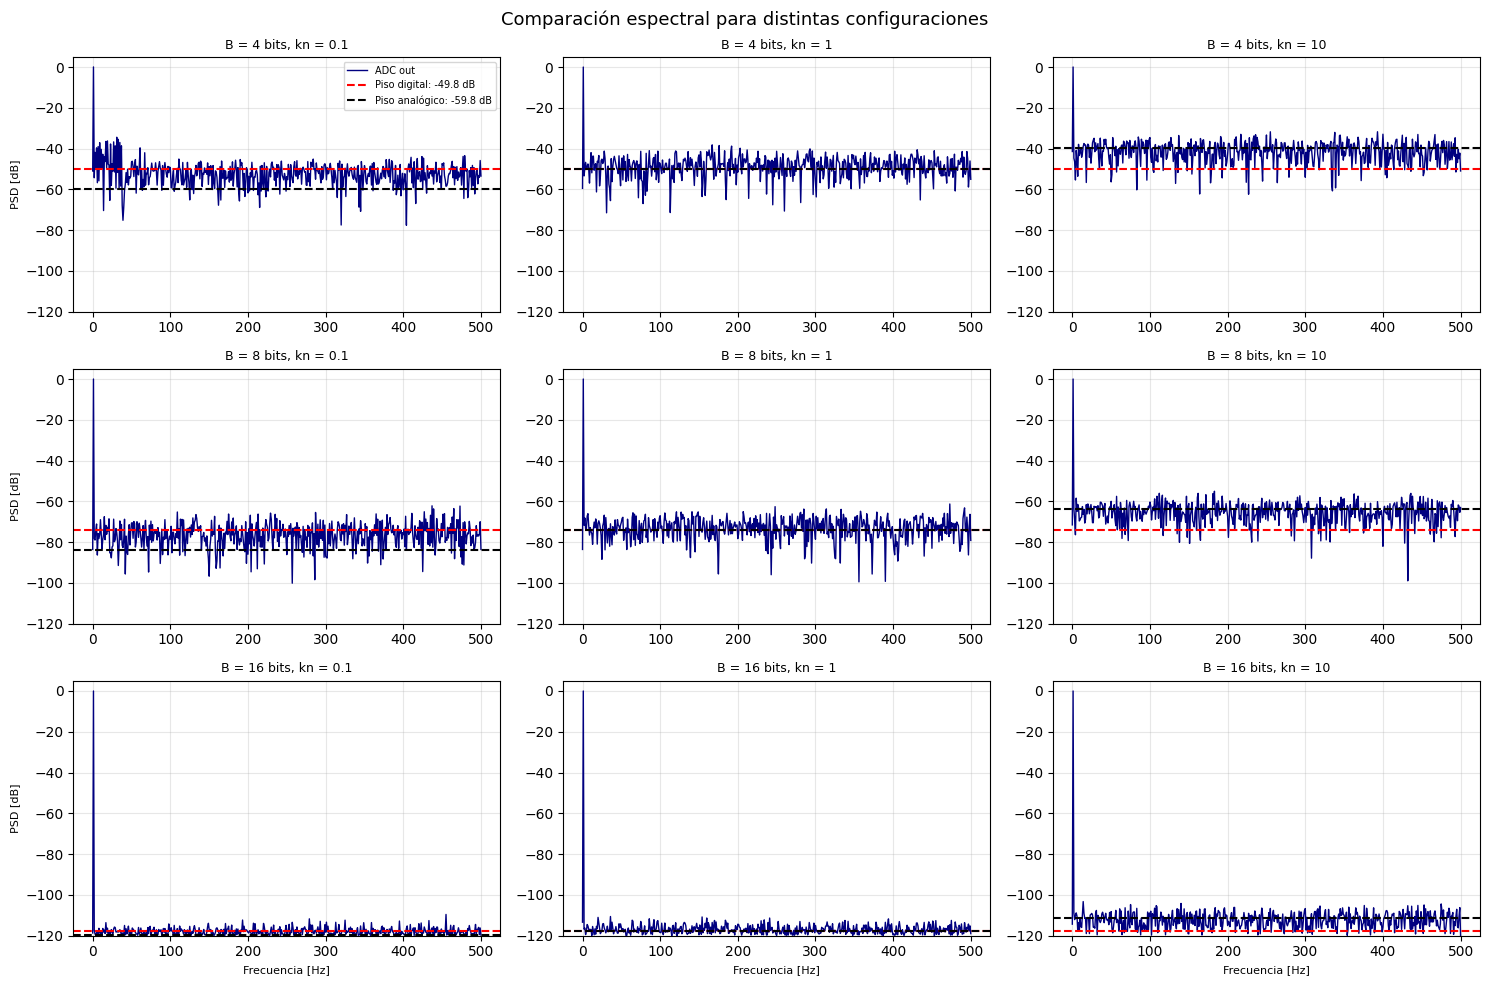

In [10]:
# ITEM B - COMPARACIÓN DE TODAS LAS CONFIGURACIONES

f0_itemB = 1
tt_itemB, s_itemB = mi_funcion_sen(vmax, dc, f0_itemB, ph, N, fs)
 
B_values  = [4, 8, 16]
kn_values = [0.1, 1, 10]
 
fig, axes = plt.subplots(len(B_values), len(kn_values), figsize=(15, 10))
 
for i, B in enumerate(B_values):
    q  = (2 * VF) / (2**B)
    Pq = q**2 / 12
 
    for j, kn in enumerate(kn_values):
        Pn = kn * Pq
 
        ruido   = np.random.normal(0, np.sqrt(Pn), N)
        sR      = s_itemB + ruido
        sR_clip = np.clip(sR, -VF, VF)
        s0      = np.round(sR_clip / q) * q
 
        S0mod = np.abs(np.fft.fft(s0)) / N
        S0psd = (S0mod**2) * 2 * N / fs
        S0db  = 10 * np.log10(S0psd + EPS)
 
        piso_q = 10 * np.log10(2 * Pq / fs + EPS)
        piso_n = 10 * np.log10(2 * Pn / fs + EPS)
 
        ax = axes[i, j]
        ax.plot(ff[bbool], S0db[bbool], color='navy', linewidth=1,
                label='ADC out' if (i == 0 and j == 0) else '')
        ax.axhline(piso_q, linestyle='--', color='red',
                   label=f'Piso digital: {piso_q:.1f} dB' if (i == 0 and j == 0) else '')
        ax.axhline(piso_n, linestyle='--', color='black',
                   label=f'Piso analógico: {piso_n:.1f} dB' if (i == 0 and j == 0) else '')
        ax.set_title(f'B = {B} bits, kn = {kn}', fontsize=9)
        ax.set_ylim(-120, 5)
        ax.grid(True, alpha=0.3)
 
        if i == len(B_values) - 1:
            ax.set_xlabel('Frecuencia [Hz]', fontsize=8)
        if j == 0:
            ax.set_ylabel('PSD [dB]', fontsize=8)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
 
plt.suptitle('Comparación espectral para distintas configuraciones', fontsize=13)
plt.tight_layout()
plt.show()


La grilla muestra cómo cambia el espectro de la señal cuantizada al variar B y kn. Al aumentar B el piso de ruido digital baja notablemente porque el paso de cuantización q es menor, efecto visible comparando las filas. Al aumentar kn sube el piso analógico, lo que se ve comparando las columnas. Cuando kn = 1 ambos pisos coinciden, consistente con que sus potencias teóricas son iguales. En conjunto el gráfico permite identificar qué ruido domina en cada caso: con B alto el limitante pasa a ser el ruido analógico, mientras que con B bajo domina el error de cuantización.

## Conclusión 
A partir de lo trabajado en ambos ítems se puede concluir que la cuantización introduce un error acotado en ±q/2 que, bajo las condiciones analizadas, se comporta como ruido blanco con distribución uniforme. Esto se verificó tanto en el histograma como en la autocorrelación, que coincidieron con los valores teóricos esperados.
Al variar B y kn se pudo ver claramente cómo cambia el comportamiento del sistema: más bits implica menos ruido de cuantización, y un kn mayor implica más ruido analógico. En cada configuración uno de los dos termina dominando, y eso determina hasta qué punto tiene sentido seguir aumentando la resolución del ADC.
En general los resultados de la simulación coincidieron con la teoría, lo que valida el modelo implementado y permite entender mejor cómo cada parámetro afecta la calidad de la señal digitalizada.